# Grade 8 Math Feature Comparison

This notebook is separate from `checkpoint1.ipynb`. It tests which engineered features improve prediction of `AVG_MATH_8_SCORE` while keeping the original checkpoint untouched.

## Prediction design

- **Forecasting target:** a state's Grade 8 math score in assessment year $t$.
- **Validation:** expanding chronological folds. Each test year is predicted using only earlier assessment years.
- **Primary metric:** mean absolute error (MAE), measured in NAEP score points. Lower is better.
- **Secondary metrics:** RMSE and out-of-sample $R^2$.
- **Model:** ridge regression with median imputation, standardization of numeric predictors, and one-hot encoding of state.
- **Fair comparison period:** 2005–2015 test years. The file has no same-year finance values for 2017 or 2019, so including those years would make the finance comparison misleading.

The notebook separates legitimate prior-information features from same-year test scores. Same-year Grade 4 and Grade 8 reading scores are reported only as a concurrent-estimation benchmark because they would not generally be available before the testing cycle.


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)


## Load and restrict the data

The analysis keeps the 50 states and removes aggregate or special jurisdictions.

In [3]:
# Look beside the notebook first, then in the course's usual data folder.
candidate_paths = [
    Path("states_edu.csv"),
    Path("../data/states_edu.csv"),
    Path("upload/states_edu.csv"),
    Path("../../upload/states_edu.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place states_edu.csv beside this notebook or in ../data/.")

raw = pd.read_csv(data_path)

# Keep the 50 states. NATIONAL, DODEA, and DC are not directly comparable state systems.
state_names = {
    'ALABAMA','ALASKA','ARIZONA','ARKANSAS','CALIFORNIA','COLORADO','CONNECTICUT','DELAWARE',
    'FLORIDA','GEORGIA','HAWAII','IDAHO','ILLINOIS','INDIANA','IOWA','KANSAS','KENTUCKY',
    'LOUISIANA','MAINE','MARYLAND','MASSACHUSETTS','MICHIGAN','MINNESOTA','MISSISSIPPI',
    'MISSOURI','MONTANA','NEBRASKA','NEVADA','NEW_HAMPSHIRE','NEW_JERSEY','NEW_MEXICO',
    'NEW_YORK','NORTH_CAROLINA','NORTH_DAKOTA','OHIO','OKLAHOMA','OREGON','PENNSYLVANIA',
    'RHODE_ISLAND','SOUTH_CAROLINA','SOUTH_DAKOTA','TENNESSEE','TEXAS','UTAH','VERMONT',
    'VIRGINIA','WASHINGTON','WEST_VIRGINIA','WISCONSIN','WYOMING'
}
df = raw[raw['STATE'].isin(state_names)].copy().sort_values(['STATE', 'YEAR']).reset_index(drop=True)

print(f"Rows after retaining 50 states: {len(df):,}")
print(f"Observed Grade 8 math scores: {df['AVG_MATH_8_SCORE'].notna().sum():,}")
print(f"Years: {df['YEAR'].min()}–{df['YEAR'].max()}")


Rows after retaining 50 states: 1,650
Observed Grade 8 math scores: 567
Years: 1986–2019


## Engineer predictors

All lagged predictors are constructed within state. Financial amounts are converted to per-pupil values and expressed relative to the median state in the same year.

In [4]:
# ---------- Enrollment denominators ----------
# ENROLL closely matches GRADES_ALL_G but has more missing values. Use ENROLL when available
# and GRADES_ALL_G as a documented fallback.
df['ENROLLMENT_BASE'] = df['ENROLL'].combine_first(df['GRADES_ALL_G'])

# ---------- Per-pupil finance variables ----------
# The source finance columns are in thousands of dollars, hence the factor of 1,000.
finance_columns = [
    'TOTAL_EXPENDITURE', 'INSTRUCTION_EXPENDITURE', 'SUPPORT_SERVICES_EXPENDITURE',
    'CAPITAL_OUTLAY_EXPENDITURE', 'TOTAL_REVENUE', 'FEDERAL_REVENUE',
    'STATE_REVENUE', 'LOCAL_REVENUE'
]
for column in finance_columns:
    pp_name = column + '_PP'
    df[pp_name] = 1000 * df[column] / df['ENROLLMENT_BASE']

    # Subtract the national median log spending in the same year. This controls for inflation
    # and national growth without requiring an external price index.
    log_pp = np.log1p(df[pp_name])
    df[pp_name + '_REL'] = log_pp - log_pp.groupby(df['YEAR']).transform('median')

# Budget and revenue composition.
df['INSTRUCTION_SHARE'] = df['INSTRUCTION_EXPENDITURE'] / df['TOTAL_EXPENDITURE']
df['SUPPORT_SHARE'] = df['SUPPORT_SERVICES_EXPENDITURE'] / df['TOTAL_EXPENDITURE']
df['CAPITAL_SHARE'] = df['CAPITAL_OUTLAY_EXPENDITURE'] / df['TOTAL_EXPENDITURE']
df['FEDERAL_SHARE'] = df['FEDERAL_REVENUE'] / df['TOTAL_REVENUE']
df['STATE_REVENUE_SHARE'] = df['STATE_REVENUE'] / df['TOTAL_REVENUE']
# LOCAL_REVENUE_SHARE is omitted because revenue shares approximately sum to one.

# Lag finance data by one calendar year so the model uses information available before testing.
finance_features_current = [
    'TOTAL_EXPENDITURE_PP_REL', 'INSTRUCTION_EXPENDITURE_PP_REL',
    'SUPPORT_SERVICES_EXPENDITURE_PP_REL', 'FEDERAL_REVENUE_PP_REL',
    'STATE_REVENUE_PP_REL', 'LOCAL_REVENUE_PP_REL', 'INSTRUCTION_SHARE',
    'SUPPORT_SHARE', 'CAPITAL_SHARE', 'FEDERAL_SHARE', 'STATE_REVENUE_SHARE'
]
for column in finance_features_current:
    df['LAG1_' + column] = df.groupby('STATE')[column].shift(1)

# Capital projects are irregular, so use the average relative capital spending over the
# three prior years rather than only the immediately preceding year.
df['CAPITAL_PP_3YR_PRIOR'] = (
    df.groupby('STATE')['CAPITAL_OUTLAY_EXPENDITURE_PP_REL']
      .transform(lambda series: series.shift(1).rolling(3, min_periods=2).mean())
)

# ---------- Enrollment features ----------
df['LOG_ENROLLMENT'] = np.log1p(df['ENROLLMENT_BASE'])
df['LAG1_LOG_ENROLLMENT'] = df.groupby('STATE')['LOG_ENROLLMENT'].shift(1)
df['LAG2_LOG_ENROLLMENT'] = df.groupby('STATE')['LOG_ENROLLMENT'].shift(2)
df['ENROLLMENT_GROWTH'] = df['LAG1_LOG_ENROLLMENT'] - df['LAG2_LOG_ENROLLMENT']
df['GRADE8_SHARE'] = df['GRADES_8_G'] / df['ENROLLMENT_BASE']
df['GRADE4_SHARE'] = df['GRADES_4_G'] / df['ENROLLMENT_BASE']
df['PRIMARY_SHARE'] = df['GRADES_1_8_G'] / df['ENROLLMENT_BASE']
df['HIGH_SCHOOL_SHARE'] = df['GRADES_9_12_G'] / df['ENROLLMENT_BASE']

# Exact four-year lag for the approximate Grade 4-to-Grade 8 cohort.
cohort = df[['STATE', 'YEAR', 'GRADES_4_G', 'AVG_MATH_4_SCORE']].copy()
cohort['YEAR'] = cohort['YEAR'] + 4
cohort = cohort.rename(columns={
    'GRADES_4_G': 'GRADE4_ENROLLMENT_4Y_AGO',
    'AVG_MATH_4_SCORE': 'MATH4_COHORT_SCORE'
})
df = df.merge(cohort, on=['STATE', 'YEAR'], how='left')
df['COHORT_SIZE_RATIO'] = df['GRADES_8_G'] / df['GRADE4_ENROLLMENT_4Y_AGO']

# ---------- Prior observed scores ----------
def prior_observed(series, k=1):
    """Return the kth most recent nonmissing value strictly before each row."""
    history = []
    result = []
    for value in series:
        result.append(history[-k] if len(history) >= k else np.nan)
        if pd.notna(value):
            history.append(value)
    return pd.Series(result, index=series.index, dtype=float)

score_columns = [
    'AVG_MATH_8_SCORE', 'AVG_MATH_4_SCORE',
    'AVG_READING_8_SCORE', 'AVG_READING_4_SCORE'
]
for column in score_columns:
    df['PRIOR_' + column] = df.groupby('STATE', group_keys=False)[column].apply(prior_observed)

# Record the year of the most recent earlier Grade 8 math observation.
observed_math8_year = df['YEAR'].where(df['AVG_MATH_8_SCORE'].notna())
df['PRIOR_MATH8_YEAR'] = (
    observed_math8_year.groupby(df['STATE'])
                       .transform(lambda series: series.shift(1).ffill())
)
df['YEARS_SINCE_MATH8'] = df['YEAR'] - df['PRIOR_MATH8_YEAR']

# Prior trend uses the two most recent earlier Grade 8 math results.
df['SECOND_PRIOR_MATH8'] = (
    df.groupby('STATE', group_keys=False)['AVG_MATH_8_SCORE']
      .apply(lambda series: prior_observed(series, k=2))
)
df['PRIOR_MATH8_TREND'] = df['PRIOR_AVG_MATH_8_SCORE'] - df['SECOND_PRIOR_MATH8']

target = 'AVG_MATH_8_SCORE'
model_data = df[df[target].notna()].copy()
print(f"Modeling rows with observed targets: {len(model_data):,}")
print("Assessment years:", sorted(model_data['YEAR'].unique()))


Modeling rows with observed targets: 567
Assessment years: [np.int64(1990), np.int64(1992), np.int64(2000), np.int64(2003), np.int64(2005), np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019)]


## Compare complete feature groups

Each test year is held out in turn, and the model trains only on earlier score years. Median imputation is fitted separately inside each training fold.

In [5]:
# Feature families.
base_features = ['STATE', 'YEAR']
prior_math8_features = ['PRIOR_AVG_MATH_8_SCORE', 'YEARS_SINCE_MATH8', 'PRIOR_MATH8_TREND']
academic_history_features = [
    'PRIOR_AVG_MATH_4_SCORE', 'PRIOR_AVG_READING_4_SCORE',
    'PRIOR_AVG_READING_8_SCORE'
]
funding_features = [
    'LAG1_TOTAL_EXPENDITURE_PP_REL', 'LAG1_INSTRUCTION_EXPENDITURE_PP_REL',
    'LAG1_SUPPORT_SERVICES_EXPENDITURE_PP_REL', 'CAPITAL_PP_3YR_PRIOR',
    'LAG1_FEDERAL_REVENUE_PP_REL', 'LAG1_STATE_REVENUE_PP_REL',
    'LAG1_LOCAL_REVENUE_PP_REL', 'LAG1_INSTRUCTION_SHARE',
    'LAG1_SUPPORT_SHARE', 'LAG1_CAPITAL_SHARE',
    'LAG1_FEDERAL_SHARE', 'LAG1_STATE_REVENUE_SHARE'
]
enrollment_features = [
    'LAG1_LOG_ENROLLMENT', 'ENROLLMENT_GROWTH', 'GRADE8_SHARE',
    'GRADE4_SHARE', 'PRIMARY_SHARE', 'HIGH_SCHOOL_SHARE', 'COHORT_SIZE_RATIO'
]
concurrent_scores = ['AVG_MATH_4_SCORE', 'AVG_READING_4_SCORE', 'AVG_READING_8_SCORE']

feature_sets = {
    '1. State + year baseline': base_features,
    '2. Prior Grade 8 math': base_features + prior_math8_features,
    '3. Academic history': base_features + prior_math8_features + academic_history_features,
    '4. Funding only': base_features + funding_features,
    '5. Enrollment only': base_features + enrollment_features,
    '6. Full forecast model': (
        base_features + prior_math8_features + academic_history_features
        + funding_features + enrollment_features
    ),
    '7. Concurrent-score benchmark': (
        base_features + prior_math8_features + academic_history_features
        + funding_features + enrollment_features + concurrent_scores
    )
}

test_years = [2005, 2007, 2009, 2011, 2013, 2015]

def make_pipeline(features):
    categorical = [column for column in features if column == 'STATE']
    numeric = [column for column in features if column != 'STATE']
    preprocessor = ColumnTransformer([
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('scale', StandardScaler())
        ]), numeric),
        ('state', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
    ])
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', Ridge(alpha=10.0))
    ])

def chronological_predictions(features):
    predictions = []
    for test_year in test_years:
        train = model_data[model_data['YEAR'] < test_year]
        test = model_data[model_data['YEAR'] == test_year]
        if train.empty or test.empty:
            continue
        pipeline = make_pipeline(features)
        pipeline.fit(train[features], train[target])
        fold = test[['STATE', 'YEAR', target]].copy()
        fold['PREDICTION'] = pipeline.predict(test[features])
        predictions.append(fold)
    return pd.concat(predictions, ignore_index=True)

def evaluate_predictions(predictions):
    actual = predictions[target]
    predicted = predictions['PREDICTION']
    return {
        'N': len(predictions),
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': mean_squared_error(actual, predicted) ** 0.5,
        'R2': r2_score(actual, predicted)
    }

group_rows = []
group_predictions = {}
for name, features in feature_sets.items():
    preds = chronological_predictions(features)
    group_predictions[name] = preds
    group_rows.append({'FEATURE SET': name, **evaluate_predictions(preds)})

group_results = pd.DataFrame(group_rows).sort_values('MAE').reset_index(drop=True)
baseline_mae = group_results.loc[group_results['FEATURE SET'] == '1. State + year baseline', 'MAE'].iloc[0]
group_results['MAE IMPROVEMENT VS BASE'] = baseline_mae - group_results['MAE']
print(group_results.round({'MAE': 3, 'RMSE': 3, 'R2': 3, 'MAE IMPROVEMENT VS BASE': 3}).to_string(index=False))


                  FEATURE SET   N   MAE  RMSE    R2  MAE IMPROVEMENT VS BASE
7. Concurrent-score benchmark 300 1.919 2.382 0.895                    2.490
       6. Full forecast model 300 2.226 2.784 0.857                    2.183
          3. Academic history 300 2.563 3.190 0.812                    1.846
        2. Prior Grade 8 math 300 2.642 3.238 0.806                    1.767
           5. Enrollment only 300 3.903 4.939 0.549                    0.506
              4. Funding only 300 3.907 4.748 0.583                    0.502
     1. State + year baseline 300 4.409 5.328 0.475                    0.000


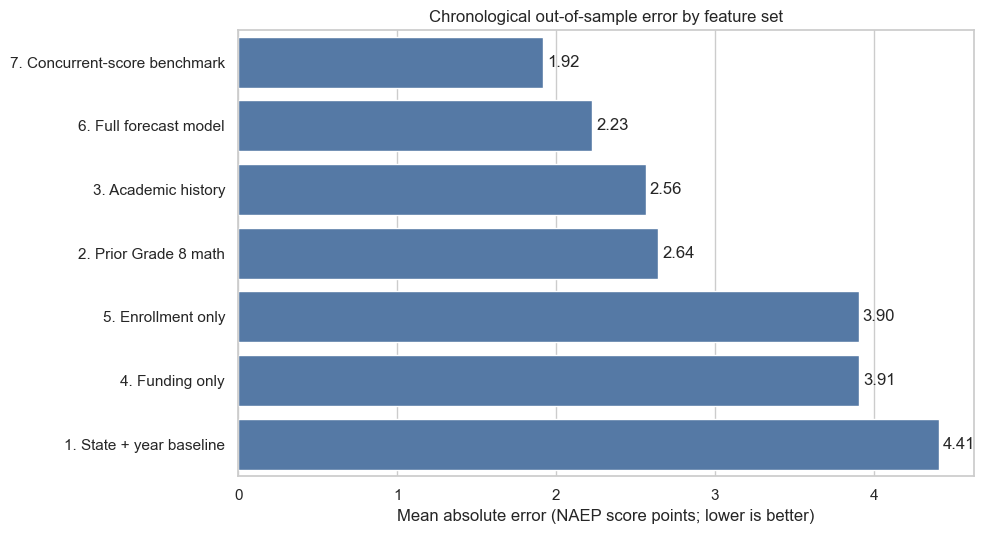

In [6]:
plot_data = group_results.sort_values('MAE', ascending=True)
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(data=plot_data, x='MAE', y='FEATURE SET', color='#4777b3')
ax.set_title('Chronological out-of-sample error by feature set')
ax.set_xlabel('Mean absolute error (NAEP score points; lower is better)')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()


## Rank individual engineered features

This is an incremental test: each candidate is added by itself to the state-and-year baseline. It measures out-of-sample predictive contribution, not causality.

In [7]:
# Add one candidate at a time to the state + year baseline.
# A positive MAE gain means the candidate improved chronological prediction.
candidate_features = list(dict.fromkeys(
    prior_math8_features + academic_history_features + funding_features + enrollment_features
))

individual_rows = []
base_predictions = chronological_predictions(base_features)
base_metrics = evaluate_predictions(base_predictions)
for feature in candidate_features:
    predictions = chronological_predictions(base_features + [feature])
    metrics = evaluate_predictions(predictions)
    individual_rows.append({
        'FEATURE': feature,
        'MAE': metrics['MAE'],
        'MAE GAIN VS BASE': base_metrics['MAE'] - metrics['MAE'],
        'R2': metrics['R2']
    })

individual_results = (
    pd.DataFrame(individual_rows)
      .sort_values('MAE GAIN VS BASE', ascending=False)
      .reset_index(drop=True)
)
print(individual_results.head(15).round(3).to_string(index=False))


                                 FEATURE   MAE  MAE GAIN VS BASE    R2
                  PRIOR_AVG_MATH_8_SCORE 2.709             1.700 0.800
               PRIOR_AVG_READING_4_SCORE 3.046             1.363 0.722
               PRIOR_AVG_READING_8_SCORE 3.707             0.702 0.582
                       HIGH_SCHOOL_SHARE 4.054             0.355 0.500
                  PRIOR_AVG_MATH_4_SCORE 4.062             0.347 0.510
           LAG1_TOTAL_EXPENDITURE_PP_REL 4.066             0.343 0.546
     LAG1_INSTRUCTION_EXPENDITURE_PP_REL 4.089             0.320 0.542
                       COHORT_SIZE_RATIO 4.183             0.226 0.514
               LAG1_LOCAL_REVENUE_PP_REL 4.189             0.220 0.543
LAG1_SUPPORT_SERVICES_EXPENDITURE_PP_REL 4.199             0.210 0.521
                            GRADE4_SHARE 4.201             0.208 0.510
                LAG1_STATE_REVENUE_SHARE 4.243             0.166 0.514
             LAG1_FEDERAL_REVENUE_PP_REL 4.246             0.163 0.506
      

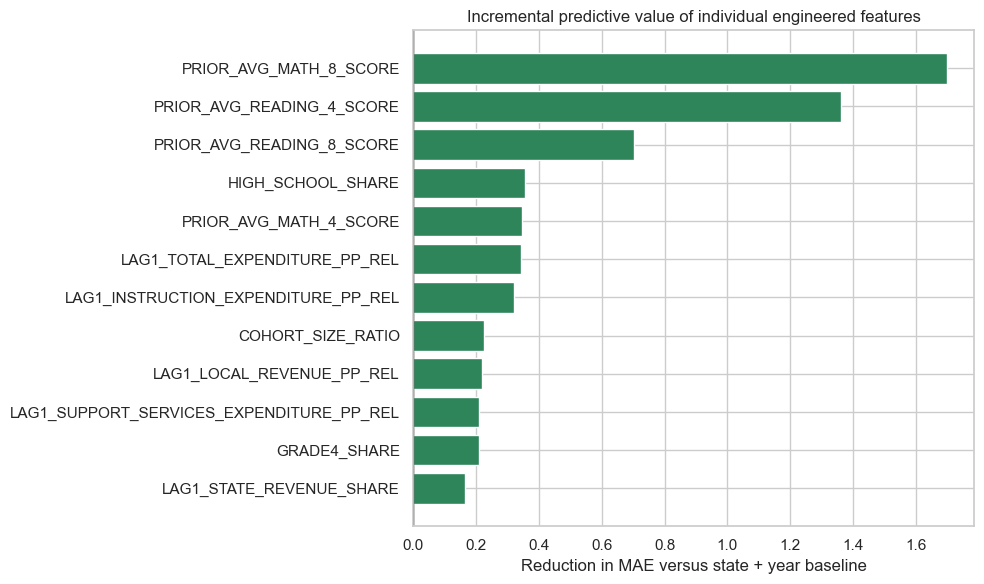

In [8]:
top_features = individual_results.head(12).sort_values('MAE GAIN VS BASE')
colors = ['#2f855a' if value > 0 else '#c53030' for value in top_features['MAE GAIN VS BASE']]
plt.figure(figsize=(10, 6))
plt.barh(top_features['FEATURE'], top_features['MAE GAIN VS BASE'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Incremental predictive value of individual engineered features')
plt.xlabel('Reduction in MAE versus state + year baseline')
plt.ylabel('')
plt.tight_layout()
plt.show()


## Stability across years

A useful feature set should improve more than one assessment year rather than benefiting only a single split.

MODEL  3. Academic history  6. Full forecast model  7. Concurrent-score benchmark
YEAR                                                                             
2005                 2.462                   2.440                          2.381
2007                 1.645                   2.188                          1.833
2009                 1.859                   1.816                          1.642
2011                 2.469                   1.905                          1.854
2013                 2.392                   1.655                          1.637
2015                 4.550                   3.351                          2.166


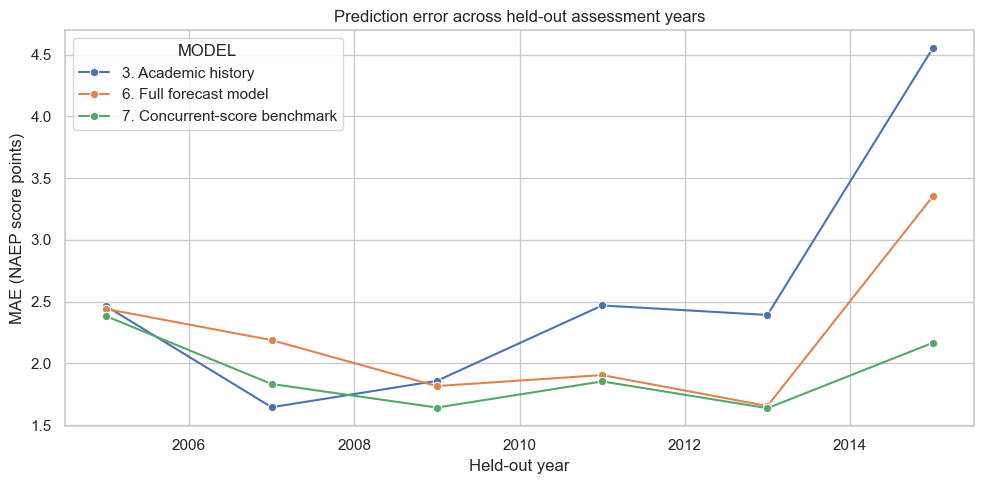

In [9]:
# Compare the most useful honest forecast with the concurrent-score benchmark by year.
models_to_compare = ['3. Academic history', '6. Full forecast model', '7. Concurrent-score benchmark']
yearly_rows = []
for name in models_to_compare:
    preds = group_predictions[name]
    for year, group in preds.groupby('YEAR'):
        yearly_rows.append({
            'MODEL': name,
            'YEAR': year,
            'MAE': mean_absolute_error(group[target], group['PREDICTION'])
        })
yearly_results = pd.DataFrame(yearly_rows)
print(yearly_results.pivot(index='YEAR', columns='MODEL', values='MAE').round(3).to_string())

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_results, x='YEAR', y='MAE', hue='MODEL', marker='o')
plt.title('Prediction error across held-out assessment years')
plt.ylabel('MAE (NAEP score points)')
plt.xlabel('Held-out year')
plt.tight_layout()
plt.show()


## Results from the saved run

- The lowest overall error came from **7. Concurrent-score benchmark**, with MAE **1.92**, RMSE **2.38**, and $R^2$ **0.895**.
- Excluding same-year test scores, the best defensible forecast specification was **6. Full forecast model**, with MAE **2.23**.
- The strongest feature when added individually to the state-and-year baseline was **`PRIOR_AVG_MATH_8_SCORE`**, improving MAE by **1.70** points.
- The prior-Grade-8 model achieved MAE **2.64**. The full forecast model achieved MAE **2.23**.

### Interpretation

Use the **academic-history or full forecast specification** for a genuine prediction exercise. Treat the concurrent-score model as an upper-bound benchmark rather than the main result. The individual rankings are predictive comparisons and should not be interpreted as evidence that spending or enrollment changes cause score changes.

### Important limitations

1. State-year observations are limited, and test scores are available only in selected years.
2. State fixed effects capture persistent differences but make it harder for slowly changing state-level variables to show incremental value.
3. The dataset ends financial coverage before the final score years. A finance-inclusive model therefore cannot be fairly validated on 2017–2019 without obtaining newer finance data.
4. Relative per-pupil financial features control for nationwide price growth, but a formal analysis should use an external inflation or education-cost index.


## Inspect the final forecast model's largest 2015 errors

In [10]:
# Optional final fit through 2013 and evaluation on 2015 for inspecting state-level errors.
selected_features = feature_sets['6. Full forecast model']
train = model_data[model_data['YEAR'] < 2015]
test = model_data[model_data['YEAR'] == 2015]
final_model = make_pipeline(selected_features)
final_model.fit(train[selected_features], train[target])

state_errors_2015 = test[['STATE', target]].copy()
state_errors_2015['PREDICTION'] = final_model.predict(test[selected_features])
state_errors_2015['ERROR'] = state_errors_2015['PREDICTION'] - state_errors_2015[target]
state_errors_2015['ABS_ERROR'] = state_errors_2015['ERROR'].abs()
print(state_errors_2015.sort_values('ABS_ERROR', ascending=False).head(10).round(2).to_string(index=False))


         STATE  AVG_MATH_8_SCORE  PREDICTION  ERROR  ABS_ERROR
       FLORIDA             275.0      283.03   8.03       8.03
      MARYLAND             283.0      289.84   6.84       6.84
  PENNSYLVANIA             284.0      290.04   6.04       6.04
       ALABAMA             267.0      272.62   5.62       5.62
        KANSAS             284.0      289.61   5.61       5.61
         MAINE             285.0      290.46   5.46       5.46
      COLORADO             286.0      291.31   5.31       5.31
SOUTH_CAROLINA             276.0      281.28   5.28       5.28
      KENTUCKY             278.0      283.24   5.24       5.24
       VERMONT             290.0      295.11   5.11       5.11
